# Parte 3 — Clientes e Pagamentos

In [82]:
%run ../src/librarys.ipynb

## 1. Carregamento dos dados

In [83]:
data = ["order_purchase_timestamp", "order_approved_at",
         "order_delivered_carrier_date", "order_delivered_customer_date",
         "order_estimated_delivery_date"]
orders = pd.read_csv("../data/processed/orders_enriched.csv", parse_dates=data)
customers = pd.read_csv("../data/processed/customers.csv")

In [84]:
orders.shape

(99441, 17)

In [85]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
order_price                             float64
order_freight                           float64
order_total                             float64
review_score                            float64
customer_state                              str
customer_city                               str
purchase_year_month                         str
dt_diff                                 float64
is_late                                 float64
dtype: object

In [86]:
customers.shape

(99441, 5)

In [87]:
print(orders.shape)
print(customers.shape)

(99441, 17)
(99441, 5)


## 2. Junção com clientes

In [88]:
tabela_base = pd.merge(orders, customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

In [89]:
tabela_base.shape

(99441, 18)

In [90]:
tabela_base["customer_unique_id"].isna().sum()

np.int64(0)

In [91]:
tabela_base['order_status'] == 'DELIVERED'

0        True
1        True
2        True
3        True
4        True
         ... 
99436    True
99437    True
99438    True
99439    True
99440    True
Name: order_status, Length: 99441, dtype: bool

In [92]:
tabela_base[tabela_base['order_status'] == 'DELIVERED']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_price,order_freight,order_total,review_score,customer_state,customer_city,purchase_year_month,dt_diff,is_late,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,DELIVERED,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,38.71,4.0,SP,SAO PAULO,2017-10,-8.0,0.0,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,DELIVERED,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,141.46,4.0,BA,BARREIRAS,2018-07,-6.0,0.0,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,DELIVERED,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,179.12,5.0,GO,VIANOPOLIS,2018-08,-18.0,0.0,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,DELIVERED,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,72.20,5.0,RN,SAO GONCALO DO AMARANTE,2017-11,-13.0,0.0,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,DELIVERED,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,28.62,5.0,SP,SANTO ANDRE,2018-02,-10.0,0.0,72632f0f9dd73dfee390c9b22eb56dd6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,DELIVERED,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,72.00,13.08,85.08,5.0,SP,SAO JOSE DOS CAMPOS,2017-03,-11.0,0.0,6359f309b166b0196dbf7ad2ac62bb5a
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,DELIVERED,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,174.90,20.10,195.00,4.0,SP,PRAIA GRANDE,2018-02,-2.0,0.0,da62f9e57a76d978d02ab5362c509660
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,DELIVERED,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,205.99,65.02,271.01,5.0,BA,NOVA VICOSA,2017-08,-6.0,0.0,737520a9aad80b3fbbdad19b66b37b30
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,DELIVERED,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,359.98,81.18,441.16,2.0,RJ,JAPUIBA,2018-01,-21.0,0.0,5097a5312c8b157bb7be58ae360ef43c


In [93]:
tabela_base[(tabela_base["order_status"] == "DELIVERED") & (tabela_base['purchase_year_month']>='2017-01') & (tabela_base['purchase_year_month']<='2018-08')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_price,order_freight,order_total,review_score,customer_state,customer_city,purchase_year_month,dt_diff,is_late,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,DELIVERED,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,38.71,4.0,SP,SAO PAULO,2017-10,-8.0,0.0,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,DELIVERED,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,141.46,4.0,BA,BARREIRAS,2018-07,-6.0,0.0,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,DELIVERED,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,179.12,5.0,GO,VIANOPOLIS,2018-08,-18.0,0.0,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,DELIVERED,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,72.20,5.0,RN,SAO GONCALO DO AMARANTE,2017-11,-13.0,0.0,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,DELIVERED,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,28.62,5.0,SP,SANTO ANDRE,2018-02,-10.0,0.0,72632f0f9dd73dfee390c9b22eb56dd6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,DELIVERED,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,72.00,13.08,85.08,5.0,SP,SAO JOSE DOS CAMPOS,2017-03,-11.0,0.0,6359f309b166b0196dbf7ad2ac62bb5a
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,DELIVERED,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,174.90,20.10,195.00,4.0,SP,PRAIA GRANDE,2018-02,-2.0,0.0,da62f9e57a76d978d02ab5362c509660
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,DELIVERED,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,205.99,65.02,271.01,5.0,BA,NOVA VICOSA,2017-08,-6.0,0.0,737520a9aad80b3fbbdad19b66b37b30
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,DELIVERED,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,359.98,81.18,441.16,2.0,RJ,JAPUIBA,2018-01,-21.0,0.0,5097a5312c8b157bb7be58ae360ef43c


## 3. Filtros do projeto
Apenas pedidos DELIVERED entre jan/2017 e ago/2018, conforme as regras do projeto. Validação: receita total de R$ 15.373.120,01, igual às tabelas agregadas." E, na seção 4: "Apenas 3,0% dos clientes compraram mais de uma vez.

In [94]:
base_filtrada = tabela_base[(tabela_base["order_status"] == "DELIVERED") & (tabela_base['purchase_year_month']>='2017-01') & (tabela_base['purchase_year_month']<='2018-08')]

In [95]:
base_filtrada.shape

(96211, 18)

In [96]:
base_filtrada['order_total'].sum()

np.float64(15373120.01)

## 4. Visão por cliente

In [97]:
clientes = base_filtrada.groupby("customer_unique_id").agg(
    pedidos=("order_id", "nunique"),
    valor_total=("order_total", "sum"),
    ultima_compra=("order_purchase_timestamp", "max")
)

In [98]:
clientes.head()

,pedidos,valor_total,ultima_compra
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,2018-05-10 10:56:27
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,2018-05-07 11:11:27
0000f46a3911fa3c0805444483337064,1,86.22,2017-03-10 21:05:03
0000f6ccb0745a6a4b88665a16c9f078,1,43.62,2017-10-12 20:29:41
0004aac84e0df4da2b147fca70cf8255,1,196.89,2017-11-14 19:45:42


In [99]:
clientes.shape

(93104, 3)

In [100]:
clientes['valor_total'].sum()

np.float64(15373120.010000002)

In [101]:
clientes["pedidos"] > 1

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    False
0000b849f77a49e4a4ce2b2a4ca5be3f    False
0000f46a3911fa3c0805444483337064    False
0000f6ccb0745a6a4b88665a16c9f078    False
0004aac84e0df4da2b147fca70cf8255    False
                                    ...  
fffcf5a5ff07b0908bd4e2dbc735a684    False
fffea47cd6d3cc0a88bd621562a9d061    False
ffff371b4d645b6ecea244b27531430a    False
ffff5962728ec6157033ef9805bacc48    False
ffffd2657e2aad2907e67c3e9daecbeb    False
Name: pedidos, Length: 93104, dtype: bool

In [102]:
recorrentes = clientes[clientes["pedidos"] > 1]

In [103]:
len(recorrentes)

2789

In [104]:
len(recorrentes) / len(clientes) * 100

2.995574841037979

In [105]:
round(len(recorrentes) / len(clientes) * 100,1)

3.0

## RFM - Recência

### 5.1 Recência
Recência = dias entre a última compra do cliente e a última data da base (29/08/2018). Mediana de 217 dias: metade dos clientes não compra há mais de 7 meses.

In [106]:
data_ref = base_filtrada["order_purchase_timestamp"].max()

In [107]:
print(data_ref)

2018-08-29 15:00:37


In [108]:
clientes['recencia'] = (data_ref - clientes['ultima_compra']).dt.days
clientes['recencia'].describe()

count    93104.000000
mean       235.702924
std        150.942219
min          0.000000
25%        113.000000
50%        217.000000
75%        344.000000
max        601.000000
Name: recencia, dtype: float64

###  5.2 Notas R, F e M
R e M divididos em quintis (notas de 1 a 5, sendo 5 o melhor). F dividido em 3 faixas (1, 2 e 3+ pedidos), porque 97% dos clientes compraram uma única vez e não é possível formar quintis. Dos clientes que compraram duas vezes, apenas 8% compraram uma terceira.

In [109]:
clientes["pedidos"].value_counts()

pedidos
1     90315
2      2562
3       180
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [110]:
clientes["F"] = pd.cut(
    clientes["pedidos"],
    bins=[0,1,2,float('inf')],
    labels=[1, 2, 3]
)

In [111]:
clientes['F'].value_counts()

F
1    90315
2     2562
3      227
Name: count, dtype: int64

In [112]:
clientes['M'] = pd.qcut(
    clientes['valor_total'],
    q=5,
    labels = [1,2,3,4,5]

)

In [113]:
clientes['R'] = pd.qcut(
    clientes['recencia'],
    q=5,
    labels = [5,4,3,2,1]
)

In [114]:
clientes['M'].value_counts()

M
1    18633
3    18622
5    18621
4    18619
2    18609
Name: count, dtype: int64

In [115]:
clientes["R"].value_counts()

R
5    18728
3    18709
4    18705
1    18589
2    18373
Name: count, dtype: int64

In [116]:
clientes.groupby("R")['recencia'].mean()

R
5     44.551848
4    134.652499
3    219.368112
2    314.625646
1    468.398946
Name: recencia, dtype: float64

In [117]:
clientes["R"] = clientes["R"].astype(int)
clientes["F"] = clientes["F"].astype(int)
clientes["M"] = clientes["M"].astype(int)

In [118]:
clientes.dtypes

pedidos                   int64
valor_total             float64
ultima_compra    datetime64[us]
recencia                  int64
F                         int64
M                         int64
R                         int64
dtype: object

In [119]:
condicoes = [
clientes["F"] >= 2,
(clientes['F'] == 1) & (clientes["R"] >= 4) & (clientes["M"] >= 4),
(clientes['F'] == 1) & (clientes['R'] >= 4) & (clientes['M'] <= 3),
(clientes['F'] == 1) & (clientes['R'] <=3) & (clientes['M'] >= 4)
]
nomes = ["Recorrentes", "Novos de alto valor", "Novos de baixo valor", "Inativos de alto valor"]
clientes["segmento"] = np.select(condicoes, nomes, default="Inativos de baixo valor")

In [120]:
clientes['segmento'].value_counts()

segmento
Inativos de baixo valor    33536
Novos de baixo valor       21766
Inativos de alto valor     20551
Novos de alto valor        14462
Recorrentes                 2789
Name: count, dtype: int64

In [121]:
resumo = clientes.groupby("segmento").agg(
clientes=("pedidos", "count"),
receita=("valor_total", "sum"),
recencia_media=("recencia", "mean")
)

In [122]:
resumo['pct_clientes'] = resumo['clientes'] / resumo['clientes'].sum() * 100

In [123]:
resumo['pct_receita'] = resumo['receita'] / resumo['receita'].sum() * 100

In [124]:
resumo.sort_values("receita", ascending=False)

,clientes,receita,recencia_media,pct_clientes,pct_receita
segmento,,,,,
Inativos de alto valor,20551,6129666.44,333.213323,22.073165,39.872625
Novos de alto valor,14462,4366678.96,90.606970,15.533167,28.404637
Inativos de baixo valor,33536,2429594.20,335.174648,36.019935,15.804171
Novos de baixo valor,21766,1586647.22,88.972342,23.378158,10.320919
Recorrentes,2789,860533.19,218.598422,2.995575,5.597648


In [125]:
resumo['receita_por_cliente'] = resumo['receita'] / resumo['clientes']

In [126]:
resumo.sort_values('receita_por_cliente', ascending=False).round(1)

,clientes,receita,recencia_media,pct_clientes,pct_receita,receita_por_cliente
segmento,,,,,,
Recorrentes,2789,860533.2,218.6,3.0,5.6,308.5
Novos de alto valor,14462,4366679.0,90.6,15.5,28.4,301.9
Inativos de alto valor,20551,6129666.4,333.2,22.1,39.9,298.3
Novos de baixo valor,21766,1586647.2,89.0,23.4,10.3,72.9
Inativos de baixo valor,33536,2429594.2,335.2,36.0,15.8,72.4


### Conclusão
Os clientes de alto valor (37,6% da base) geraram 68,3% da receita. A prioridade são os novos de alto valor: 15,5% dos clientes, 28,4% da receita e última compra há 91 dias em média. Partindo do princípio de que manter um cliente recente tende a custar menos que reativar um antigo, convertê-los numa segunda compra é a ação de melhor retorno. Os inativos de alto valor concentram 39,9% da receita, mas não compram há 11 meses em média; recomenda-se testar campanhas de reativação antes de investir em escala. Os grupos de baixo valor (R$ 73 por cliente) devem receber apenas ações de baixo custo, como frete grátis acima de um valor mínimo.

## 6. Análise de Coorte

In [127]:
primeira = base_filtrada.groupby("customer_unique_id").agg(
    primeira_compra=("order_purchase_timestamp", "min")
)

In [128]:
primeira.shape

(93104, 1)

In [129]:
primeira = primeira.reset_index()

In [130]:
primeira.head()

,customer_unique_id,primeira_compra
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [131]:
coorte_base = pd.merge(base_filtrada, primeira, on="customer_unique_id", how="left")

In [132]:
coorte_base.shape

(96211, 19)

In [133]:
coorte_base["mes_coorte"] = coorte_base["primeira_compra"].dt.to_period("M")

In [134]:
coorte_base["mes_indice"] = (
    (coorte_base["order_purchase_timestamp"].dt.year - coorte_base["primeira_compra"].dt.year) * 12
    + (coorte_base["order_purchase_timestamp"].dt.month - coorte_base["primeira_compra"].dt.month)
)

In [135]:
coorte_base[coorte_base['mes_indice'] == 0]['customer_unique_id'].nunique()

93104

In [136]:
coorte_base.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_price', 'order_freight', 'order_total', 'review_score',
       'customer_state', 'customer_city', 'purchase_year_month', 'dt_diff',
       'is_late', 'customer_unique_id', 'primeira_compra', 'mes_coorte',
       'mes_indice'],
      dtype='str')

In [137]:
tabela_coorte = coorte_base.pivot_table(
index="mes_coorte",
columns="mes_indice",
values="customer_unique_id",
aggfunc="nunique"
)

In [138]:
tabela_coorte.head()

mes_indice,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19
mes_coorte,,,,,,,,,,,,,,,,,,,
2017-01,718.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN
2017-04,2257.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN
2017-05,3451.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN


In [139]:
tabela_coorte[0].sum()

np.float64(93104.0)

In [140]:
retencao = tabela_coorte.divide(tabela_coorte[0], axis=0) * 100

In [141]:
retencao.head().round(2)

mes_indice,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19
mes_coorte,,,,,,,,,,,,,,,,,,,
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN


In [142]:
retencao[1].mean().round(2)

np.float64(0.48)

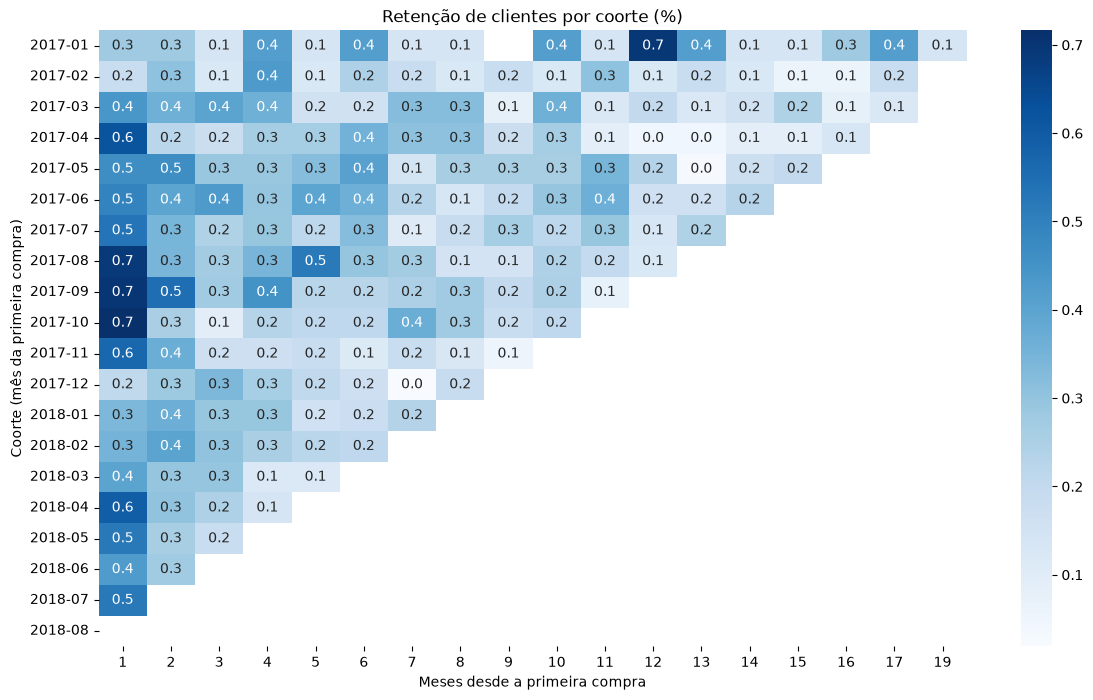

In [143]:
plt.figure(figsize=(14, 8))
sns.heatmap(retencao.iloc[:, 1:], annot=True, fmt=".1f", cmap="Blues")
plt.title("Retenção de clientes por coorte (%)")
plt.xlabel("Meses desde a primeira compra")
plt.ylabel("Coorte (mês da primeira compra)")
plt.show()

In [144]:
retencao = retencao.reindex(columns=range(0, 20))

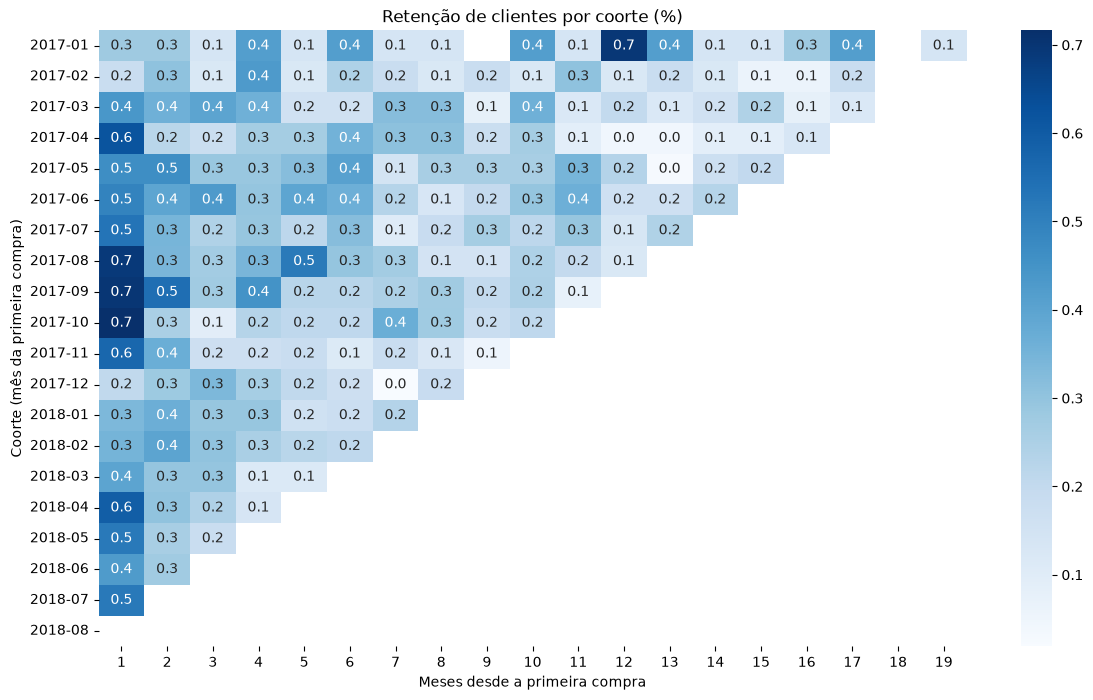

In [145]:
plt.figure(figsize=(14, 8))
sns.heatmap(retencao.iloc[:, 1:], annot=True, fmt=".1f", cmap="Blues")
plt.title("Retenção de clientes por coorte (%)")
plt.xlabel("Meses desde a primeira compra")
plt.ylabel("Coorte (mês da primeira compra)")
plt.show()

In [146]:
coortes_com_mes1 = tabela_coorte[1].notna()
tabela_coorte.loc[coortes_com_mes1, 1].sum() / tabela_coorte.loc[coortes_com_mes1, 0].sum() * 100

np.float64(0.4829806807727691)

## Conclusão
Em média, 0,48% dos clientes voltam a comprar no mês seguinte à primeira compra (média ponderada pelo tamanho das coortes). Nos meses seguintes, a retenção fica entre 0,1% e 0,7%, sem um padrão de queda gradual: praticamente toda a perda acontece entre a primeira compra e o mês seguinte.

A retenção não melhorou ao longo do tempo: as coortes de 2018 retêm na mesma faixa que as de 2017, inclusive a coorte de novembro/2017 (Black Friday). Ou seja, o crescimento de receita do período veio da aquisição de novos clientes, não de uma base mais fiel.

Esse resultado confirma, por outro caminho, o achado do RFM: 97% dos clientes compraram uma única vez. As duas análises apontam para o mesmo ponto crítico, a segunda compra, e reforçam a prioridade sobre os clientes novos, que ainda estão no período em que o retorno é mais provável.

Nota de leitura do gráfico: células vazias no meio da tabela indicam que nenhum cliente da coorte comprou naquele mês; o triângulo vazio no canto inferior direito corresponde a meses que ainda não haviam ocorrido no período dos dados.

## 7. Previsão de receita

In [147]:
mensal = pd.read_csv("../data/processed/agg_mensal.csv")
mensal.head()

,purchase_year_month,pedidos,receita,ticket_medio,crescimento_receita_pct
0,2017-01,750,127482.37,169.976493,NaN
1,2017-02,1653,271239.32,164.089123,112.766142
2,2017-03,2546,414330.95,162.738001,52.754752
3,2017-04,2303,390812.40,169.697091,-5.676272
4,2017-05,3546,566851.40,159.856571,45.044374


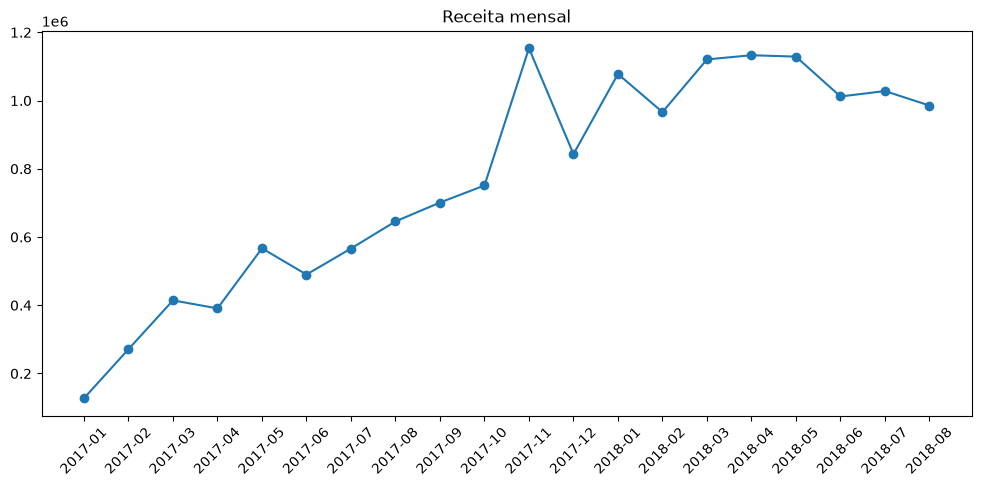

In [148]:
plt.figure(figsize=(12,5))
plt.plot(mensal['purchase_year_month'], mensal['receita'], marker='o')
plt.title('Receita mensal')
plt.xticks(rotation=45)
plt.show()

In [149]:
mensal.shape

(20, 5)

In [150]:
mensal["t"] = range(len(mensal))

treino = mensal[mensal["purchase_year_month"] <= "2018-05"]
teste = mensal[mensal["purchase_year_month"] >= "2018-06"]

In [151]:
treino.shape

(17, 6)

In [152]:
teste.shape

(3, 6)

In [153]:
inclinacao, intercepto = np.polyfit(treino["t"], treino["receita"], 1)
print(inclinacao, intercepto)

62595.19889705883 225582.10294117656


In [154]:
prev_A = inclinacao * teste["t"] + intercepto

In [155]:
treino.tail(3)

,purchase_year_month,pedidos,receita,ticket_medio,crescimento_receita_pct,t
14,2018-03,7003,1120598.24,160.016884,15.983738,14
15,2018-04,6798,1132878.93,166.648857,1.095905,15
16,2018-05,6749,1128774.52,167.250633,-0.362299,16


In [156]:
prev_B = treino["receita"].tail(3).mean()

In [157]:
print(prev_B)

1127417.23


In [158]:
inclinacao, intercepto = np.polyfit(treino["t"], treino["receita"], 1)
print(inclinacao, intercepto)

prev_A = inclinacao * teste["t"] + intercepto

erro_A = (abs(prev_A - teste["receita"]) / teste["receita"]).mean() * 100
erro_B = (abs(prev_B - teste["receita"]) / teste["receita"]).mean() * 100
print(erro_A, erro_B)

62595.19889705883 225582.10294117656
34.1955051191644 11.833418828486913


In [159]:
prev_final = mensal["receita"].tail(3).mean()

In [160]:
limite_inferior = prev_final * (1 - erro_B / 100)
limite_superior = prev_final * (1 + erro_B / 100)
print(prev_final, limite_inferior, limite_superior)

1008425.7366666667 889094.4956726454 1127756.9776606879


A previsão não incorpora sazonalidade; novembro tende a superar a faixa por efeito da Black Friday, observado uma única vez na série.

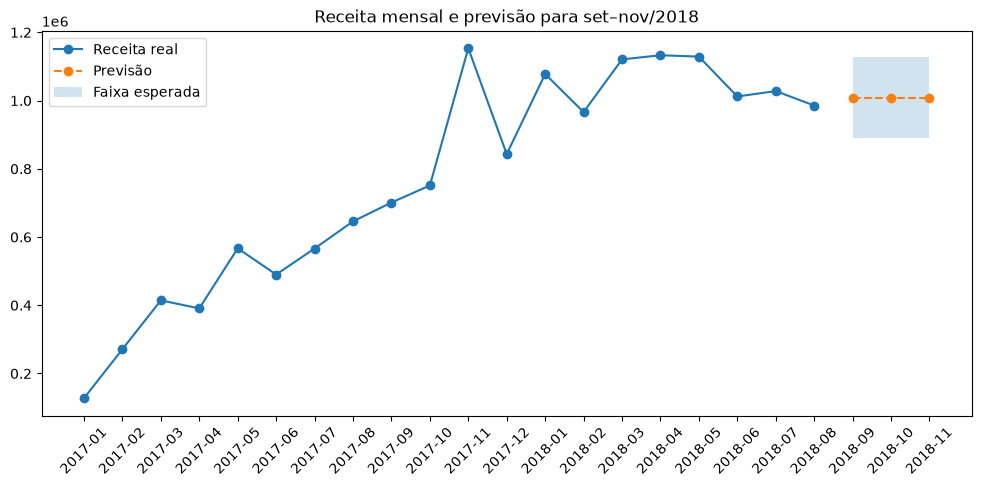

In [161]:
meses_prev = ["2018-09", "2018-10", "2018-11"]

plt.figure(figsize=(12, 5))
plt.plot(mensal["purchase_year_month"], mensal["receita"], marker="o", label="Receita real")
plt.plot(meses_prev, [prev_final] * 3, marker="o", linestyle="--", label="Previsão")
plt.fill_between(meses_prev, limite_inferior, limite_superior, alpha=0.2, label="Faixa esperada")
plt.title("Receita mensal e previsão para set–nov/2018")
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Conclusão da previsão
Foram testados dois modelos, usando jan/2017 a mai/2018 como treino e jun–ago/2018 como teste:

Tendência linear: erro médio de 34,2%. O modelo aprendeu o crescimento de 2017 (cerca de R$ 62,6 mil a mais por mês) e previu que ele continuaria, quando a receita de 2018 já havia se estabilizado.
Média dos 3 meses mais recentes: erro médio de 11,8%.

A média recente foi escolhida por errar quase três vezes menos. O resultado mostra que, após a fase de crescimento de 2017, o negócio entrou em uma fase de estabilidade, e os dados antigos deixaram de representar o comportamento atual.

Previsão para set–nov/2018: cerca de R$ 1,01 milhão por mês, com faixa esperada entre R$ 889 mil e R$ 1,13 milhão (baseada no erro medido no teste). No trimestre, cerca de R$ 3,0 milhões (entre R$ 2,7 e 3,4 milhões).

Limitações:

A série tem apenas 20 meses, o que limita a escolha de modelos.
A previsão não incorpora sazonalidade: há apenas um novembro na série. Em 2017, a Black Friday elevou a receita de novembro em cerca de 50% em relação a outubro; se o efeito se repetir, novembro/2018 tende a superar o limite superior da faixa.
No teste, o modelo errou sempre para cima. Parte da queda de jun–ago/2018 pode refletir pedidos do fim do período ainda não entregues na extração dos dados, já que apenas pedidos entregues são considerados.

## 8. Pagamentos
Considerados apenas pedidos entregues entre jan/2017 e ago/2018, para manter consistência com as demais análises e com a receita validada.

In [162]:
payments = pd.read_csv("../data/processed/payments.csv")

pag = payments[payments["order_id"].isin(base_filtrada["order_id"])]

In [164]:
pag.shape

(100473, 5)

In [165]:
pag['order_id'].nunique()

96211

In [166]:
pag['payment_value'].sum()

np.float64(15375875.440000001)

In [167]:
formas = pag.groupby("payment_type").agg(
    pedidos=("order_id", "nunique"),
    valor=("payment_value", "sum")
)

In [172]:
formas["pct_pedidos"] = formas["pedidos"] / pag["order_id"].nunique() * 100

In [170]:
formas['pct_valor'] = formas['valor'] / formas['valor'].sum()*100

In [173]:
formas.sort_values('pedidos',ascending=True)

,pedidos,valor,pct_pedidos,pct_valor
payment_type,,,,
DEBIT_CARD,1483,208179.39,1.541404,1.353935
VOUCHER,3670,342294.66,3.814533,2.226180
BOLETO,19140,2762300.80,19.893775,17.965161
CREDIT_CARD,74095,12063100.59,77.013023,78.454724


In [174]:
cartao = pag[pag["payment_type"] == "CREDIT_CARD"]

In [175]:
cartao["payment_installments"].value_counts().sort_index()

payment_installments
0         2
1     24710
2     12050
3     10130
4      6869
5      5079
6      3789
7      1554
8      4133
9       615
10     5116
11       22
12      128
13       15
14       14
15       72
16        5
17        7
18       27
20       16
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [176]:
cartao['payment_installments'].mean()

np.float64(3.49892438420996)

In [177]:
cartao.groupby('payment_installments')['payment_value'].mean()

payment_installments
0      94.315000
1      95.628085
2     126.552255
3     142.052096
4     163.698234
5     182.181611
6     208.678266
7     186.151840
8     306.303380
9     198.111837
10    410.527842
11    125.597273
12    324.408672
13    151.826667
14    169.360000
15    431.128194
16    292.694000
17    174.522857
18    486.483333
20    641.784375
21    243.700000
22    228.710000
23    236.480000
24    610.048889
Name: payment_value, dtype: float64

In [178]:
cartao = cartao[cartao["payment_installments"] >= 1].copy()

cartao["faixa_parcelas"] = pd.cut(
    cartao["payment_installments"],
    bins=[0, 1, 3, 6, 10, float("inf")],
    labels=["1x", "2-3x", "4-6x", "7-10x", "11x+"]
)

In [179]:
cartao["faixa_parcelas"].value_counts().sort_index()


faixa_parcelas
1x       24710
2-3x     22180
4-6x     15737
7-10x    11418
11x+       329
Name: count, dtype: int64

In [181]:
cartao.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'faixa_parcelas'],
      dtype='str')

In [185]:
parcelas = cartao.groupby("faixa_parcelas", observed=True).agg(
    pagamentos=("payment_type", "count"),
    valor_medio=("payment_value", "mean"),
    valor_total=("payment_value","sum")
)


In [189]:
parcelas["pct_pagamentos"] = parcelas["pagamentos"] / parcelas["pagamentos"].sum() * 100

In [190]:
parcelas['pct_valor'] = parcelas['valor_total'] / parcelas['valor_total'].sum()*100

In [193]:
parcelas[["pagamentos", "pct_pagamentos", "valor_medio", "valor_total", "pct_valor"]].round(1)

,pagamentos,pct_pagamentos,valor_medio,valor_total,pct_valor
faixa_parcelas,,,,,
1x,24710,33.2,95.6,2362970.0,19.6
2-3x,22180,29.8,133.6,2963942.4,24.6
4-6x,15737,21.2,180.5,2840425.5,23.5
7-10x,11418,15.4,330.8,3777331.0,31.3
11x+,329,0.4,359.4,118243.0,1.0


## Conclusão
Considerados apenas os pagamentos dos pedidos entregues entre jan/2017 e ago/2018, para manter consistência com as demais análises.

Formas de pagamento: o cartão de crédito domina, presente em 77% dos pedidos e responsável por 78% do valor pago. O boleto aparece em 20% dos pedidos. O voucher está em 4% dos pedidos, mas em apenas 2% do valor, o que indica uso como complemento de outra forma de pagamento. (A soma das porcentagens de pedidos passa de 100% porque alguns pedidos usam mais de uma forma de pagamento.)

Parcelamento no cartão: dois terços dos pagamentos são parcelados, com média de 3,5 parcelas. O valor médio cresce com o número de parcelas, de R$ 96 à vista para R$ 331 entre 7 e 10x. Essa faixa concentra 31% do valor pago no cartão com apenas 15% dos pagamentos, enquanto os pagamentos à vista são 33% da quantidade e só 20% do valor. Os picos em 8x e 10x sugerem ofertas de parcelamento sem juros, e 10x funciona como limite prático: acima disso estão apenas 0,4% dos pagamentos.

Validação: o valor total pago coincide com a receita dos pedidos (diferença de 0,02%), o que confirma a base usada no RFM. Dois pagamentos com 0 parcelas foram desconsiderados por inconsistência.

Hipótese para aprofundar: verificar se os clientes de alto valor do RFM parcelam mais. Se confirmado, as condições de parcelamento seriam uma alavanca direta para os segmentos prioritários.